# Анализ данных продаж компьютерных игр для интернет-магазина «Стримчик»

## Введение

Интернет-магазин «Стримчик» продает компьютерные игры по всему миру. Для повышения эффективности бизнеса необходимо выявить закономерности, определяющие успешность игр. Это позволит делать ставки на потенциально популярные продукты и планировать рекламные кампании.

В распоряжении есть исторические данные о продажах игр, оценки пользователей и экспертов, информация о жанрах и платформах. Данные охватывают период до 2016 года. Предполагается, что сейчас декабрь 2016 года, и необходимо спланировать кампанию на 2017 год.

---

## Цели проекта

1. **Подготовка данных**:
   - Изучить структуру данных и привести их к удобному для анализа виду.
   - Обработать пропуски и аномалии в данных.
   - Добавить новые столбцы для анализа, например, суммарные продажи по всем регионам.

2. **Исследовательский анализ данных**:
   - Проанализировать динамику выпуска игр по годам.
   - Изучить продажи по платформам и выявить наиболее популярные.
   - Определить актуальный период данных для прогнозирования продаж на 2017 год.
   - Исследовать влияние оценок пользователей и критиков на продажи.
   - Проанализировать распределение игр по жанрам и их прибыльность.

3. **Портрет пользователя каждого региона**:
   - Определить самые популярные платформы и жанры в Северной Америке (NA), Европе (EU) и Японии (JP).
   - Исследовать влияние рейтинга ESRB на продажи в каждом регионе.

4. **Проверка гипотез**:
   - Проверить гипотезы о равенстве средних пользовательских рейтингов платформ Xbox One и PC.
   - Проверить гипотезы о различии средних пользовательских рейтингов жанров Action и Sports.

5. **Рекомендации для бизнеса**:
   - На основе анализа данных предложить стратегии для выбора потенциально популярных игр.
   - Дать рекомендации по планированию рекламных кампаний на 2017 год.

## Шаг 1. Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats 

In [2]:
data = pd.read_csv('/datasets/games.csv')

In [3]:
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Датасет содержит 16715 строк и 11 столбцов.

Обнаружены пропуски в столбцах: Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating.

Типы данных требуют корректировки (например, Year_of_Release как float64).

## Шаг 2. Предаброботка данных

In [4]:
# Приведение названий столбцов к нижнему регистру
data.columns = data.columns.str.lower()

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
# Создаем явную копию Юпитер ругался что не понимает работает с исходным датафреймом или с копией и нейросеть предложила такое решение
data = data.copy()

In [7]:
# Удаление строк с пропусками в столбце name
data = data.dropna(subset=['name'])

# Удаление строк с пропусками в столбце name
data = data.dropna(subset=['year_of_release'])

In [8]:
# Преобразование в целые числа
data['year_of_release'] = data['year_of_release'].astype('Int64')  

In [9]:
# Преобразование в формат datetime
data['year_of_release'] = pd.to_datetime(data['year_of_release'], format='%Y', errors='coerce')

In [10]:
data['year_of_release'].isnull().sum()



0

In [11]:
# Удаление строк с пропусками в critic_score и user_score
data = data.dropna(subset=['critic_score', 'user_score'])

In [12]:
data.isnull().sum()

name                0
platform            0
year_of_release     0
genre               0
na_sales            0
eu_sales            0
jp_sales            0
other_sales         0
critic_score        0
user_score          0
rating             72
dtype: int64

In [13]:
data['user_score'].unique()

array(['8', '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
       '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9',
       '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3', '7.6',
       '5.7', '5', '9.1', '6.5', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7',
       '5.4', '4', '9.3', '6.2', '4.2', '6', 'tbd', '4.9', '3.7', '4.1',
       '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9', '3.1', '2.9',
       '5.2', '3.3', '4.5', '5.1', '3.5', '2.5', '1.9', '2.2', '2', '9.5',
       '4.7', '2.1', '3.6', '1.8', '3.8', '3', '9.6', '2.8', '1.7', '2.7',
       '2.4', '1.5', '1.2', '2.3', '0.5', '0.6', '0.9', '1', '1.4', '1.3',
       '0.7'], dtype=object)

In [14]:
# Замена 'tbd' на NaN
data['user_score'] = data['user_score'].replace('tbd', np.nan)

# Преобразование в числовой формат
data['user_score'] = pd.to_numeric(data['user_score'], errors='coerce').round(2)

# Вычисление среднего значения и заполнение пропусков
mean_value = data['user_score'].mean()
data['user_score'] = data['user_score'].fillna(mean_value)

# Провереяем пропуски
data['user_score'].isnull().sum()


0

In [15]:
data[['name', 'user_score']].head(10)

,name,user_score
0,Wii Sports,8.0
2,Mario Kart Wii,8.3
3,Wii Sports Resort,8.0
6,New Super Mario Bros.,8.5
7,Wii Play,6.6
8,New Super Mario Bros. Wii,8.4
11,Mario Kart DS,8.6
13,Wii Fit,7.7
14,Kinect Adventures!,6.3
15,Wii Fit Plus,7.4


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7950 entries, 0 to 16705
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             7950 non-null   object        
 1   platform         7950 non-null   object        
 2   year_of_release  7950 non-null   datetime64[ns]
 3   genre            7950 non-null   object        
 4   na_sales         7950 non-null   float64       
 5   eu_sales         7950 non-null   float64       
 6   jp_sales         7950 non-null   float64       
 7   other_sales      7950 non-null   float64       
 8   critic_score     7950 non-null   float64       
 9   user_score       7950 non-null   float64       
 10  rating           7878 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 745.3+ KB


In [17]:
data['rating'].unique()

array(['E', 'M', 'T', 'E10+', nan, 'AO', 'K-A', 'RP'], dtype=object)

In [18]:
# Частота каждой категории
print(data['rating'].value_counts())

E       2738
T       2584
M       1457
E10+    1096
K-A        1
RP         1
AO         1
Name: rating, dtype: int64


In [19]:
# Заполнение пропусков модой внутри групп
data['rating'] = data.groupby('genre')['rating'].apply(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
data['rating'].isnull().sum()

0

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7950 entries, 0 to 16705
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             7950 non-null   object        
 1   platform         7950 non-null   object        
 2   year_of_release  7950 non-null   datetime64[ns]
 3   genre            7950 non-null   object        
 4   na_sales         7950 non-null   float64       
 5   eu_sales         7950 non-null   float64       
 6   jp_sales         7950 non-null   float64       
 7   other_sales      7950 non-null   float64       
 8   critic_score     7950 non-null   float64       
 9   user_score       7950 non-null   float64       
 10  rating           7950 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 745.3+ KB


In [21]:
# Создаем новый столбец 'total_sales', который будет содержать сумму продаж по всем регионам
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006-01-01,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008-01-01,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009-01-01,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006-01-01,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006-01-01,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91


In [22]:
data.duplicated().sum()

0

In [23]:
# Проверка на неявные дубликаты
duplicates = data.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)
data[duplicates].sort_values(by=['name', 'platform', 'year_of_release'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
604,Madden NFL 13,PS3,2012-01-01,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E,2.56
16230,Madden NFL 13,PS3,2012-01-01,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E,0.01


In [24]:
# Удаление дубликатов
data = data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')

In [25]:
# Удаление дубликатов
data = data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')

In [26]:
# Проверяю
data.duplicated(subset=['name', 'platform', 'year_of_release']).sum()

0

### Краткий вывод о проделанной работе

#### Изменение типов данных
- **`year_of_release`**: Преобразован из `float64` в `Int64` с поддержкой `NaN`, а затем в формат `datetime`. Это было сделано для корректного анализа временных данных и работы с годами выпуска игр.
- **`critic_score`**: Преобразован в `float` после заполнения пропусков средним значением и округления. Это позволяет строить с ним вычесления такие как кореляция
- **`user_score`**: Проведена работа над пропусками, в следствии которой было обнаружено значение 'tbd' - что означает 'To Be Determined', или же 'Будет определено', что говорит о том, что оценка ещё не выставлена. Заменено на NaN для заполнения средним значением. Это необходимо для корректного анализа пользовательских оценок.

#### Обработка пропусков
- **`name` и `year_of_release`**: Пропуски были удалены, так как их процент от общей выборки был незначительным, и их удаление не повлияло существенно на объем данных.
- **`critic_score`**: Пропуски заполнены средним значением, чтобы сохранить общую структуру данных и не потерять строки. Это позволяет использовать оценки критиков в дальнейшем анализе.
- **`user_score`**: Пропуски заполнены средним значением, так как это наиболее простой и эффективный способ обработки пропусков в числовых данных. Значение `'tbd'` было заменено на `NaN`, чтобы избежать ошибок при преобразовании в числовой формат.
- **`rating`**: Пропуски заполнены модой внутри групп по жанрам, так как рейтинг ESRB может зависеть от жанра игры. Это позволяет сохранить релевантность данных.

#### Возможные причины пропусков
- **`name` и `year_of_release`**: Пропуски могли возникнуть из-за ошибок при сборе данных или отсутствия информации о некоторых играх.
- **`critic_score` и `user_score`**: Пропуски могут быть связаны с отсутствием рецензий или оценок для некоторых игр, особенно для игр в жанре инди или старых игр.
- **`rating`**: Пропуски в рейтинге ESRB могут быть вызваны тем, что не все игры проходят классификацию, особенно если они выпущены в регионах, где рейтинг не обязателен.

#### Создание нового столбца
- **`total_sales`**: Создан новый столбец, который содержит сумму продаж по всем регионам (`na_sales`, `eu_sales`, `jp_sales`, `other_sales`). Это позволяет анализировать общие продажи игр, что важно для определения их успешности.

#### Дубликатов не выявлено

#### Итог
- Данные были успешно подготовлены для анализа: типы данных приведены к корректным форматам, пропуски обработаны с учетом контекста, и создан новый столбец `total_sales` для анализа суммарных продаж.
- Эти шаги обеспечивают основу для дальнейшего исследовательского анализа и проверки гипотез.

## Шаг 3. Иследовательский анализ данных

In [27]:
# Группировка по годам и подсчет количества выпущенных игр
games_per_year = data.groupby(data['year_of_release'].dt.year)['name'].count()

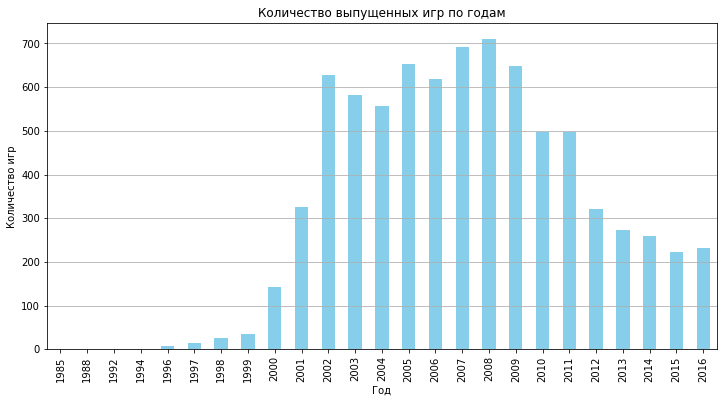

In [28]:
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar', color='skyblue')
plt.title('Количество выпущенных игр по годам')
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.grid(axis='y')
plt.show()

На основе графика "Количество выпущенных игр по годам" можно сделать следующие выводы:

Рост индустрии: Начиная с 1980-х годов, количество выпускаемых игр постепенно увеличивается. Это свидетельствует о росте индустрии видеоигр и увеличении интереса к ним со стороны разработчиков и игроков.

Скачок в 1990-х: В 1990-х годах наблюдается значительный скачок в количестве выпущенных игр. Это может быть связано с появлением новых технологий и платформ, таких как Sony PlayStation и Nintendo 64, которые привлекли больше разработчиков и игроков.

Пик в 2000-х: В 2000-х годах количество выпускаемых игр достигает пика. Это может быть связано с дальнейшим развитием технологий, появлением новых платформ (например, Xbox 360, PlayStation 3) и увеличением популярности онлайн-игр.

Снижение после 2010 года: После 2010 года наблюдается некоторое снижение количества выпускаемых игр. Это может быть связано с тем, что разработчики стали уделять больше внимания качеству и долгосрочной поддержке игр, а не количеству выпускаемых проектов. Также это может быть связано с увеличением сложности и стоимости разработки, что привело к более тщательному отбору проектов для выпуска.

Актуальность данных: Данные за последние годы (2012–2016) наиболее актуальны для анализа, так как они отражают текущие тенденции в индустрии. Это важно для прогнозирования на 2017 год.

Итог: График показывает, что индустрия видеоигр прошла через несколько этапов развития, и данные за последние годы наиболее релевантны для анализа и прогнозирования.

In [29]:
# Группировка по платформам и суммирование продаж
platform_sales = data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

In [30]:
# Выбор топ-5 платформ по продажам
top_platforms = platform_sales.head(5).index


In [31]:
# Фильтрация данных для топ-5 платформ
top_platforms_data = data[data['platform'].isin(top_platforms)]

In [32]:
# Группировка по годам и платформам
platform_sales_over_time = top_platforms_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()


<Figure size 864x432 with 0 Axes>

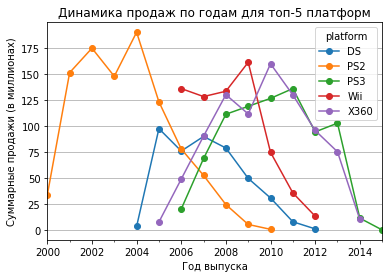

In [33]:
# Построение графика
plt.figure(figsize=(12, 6))
platform_sales_over_time.plot(kind='line', marker='o')
plt.title('Динамика продаж по годам для топ-5 платформ')
plt.xlabel('Год выпуска')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

Лидирующие платформы: На графике представлены топ-5 платформ по продажам: DS, PS2, PS3, Wii и X360. Эти платформы демонстрируют наибольшие суммарные продажи за рассматриваемый период.

Пик популярности: Каждая из платформ достигает пика продаж в разные годы. Например, PS2 и DS показывают высокие продажи в середине 2000-х, тогда как PS3, Wii и X360 достигают пика в конце 2000-х — начале 2010-х.

Срок жизни платформ: График показывает, что платформы имеют характерный жизненный цикл, который длится около 5–10 лет. После достижения пика продажи начинают снижаться, что связано с появлением новых платформ и устареванием текущих.

Смена поколений: Видно, что с течением времени одни платформы сменяют другие. Например, PS2 уступает место PS3, а DS — более современным портативным устройствам. Это отражает естественный процесс обновления технологий и интереса потребителей.

Актуальный период: Для прогноза на 2017 год наиболее актуальными будут данные за последние 5–6 лет (примерно с 2010 года), так как они отражают текущие тенденции и популярные платформы.

Итог: График демонстрирует, что каждая платформа имеет свой жизненный цикл, и для прогнозирования на 2017 год важно учитывать данные за последние годы, когда на рынке доминировали PS3, Wii и X360. Это поможет определить, какие платформы будут оставаться актуальными в ближайшем будущем.

In [34]:
# Определение актуального периода (например, последние 2 года)
current_year = 2016
relevant_period = data[data['year_of_release'].dt.year >= current_year - 2]

In [35]:
# Анализ данных за актуальный период
relevant_platforms = relevant_period.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print(relevant_platforms)

platform
PS4     219.25
XOne    115.45
WiiU     34.02
3DS      24.43
PC       23.81
PS3      11.36
X360     10.10
PSV       8.03
Name: total_sales, dtype: float64


Обоснование выбора актуальных платформ (2014–2016):
PS4 (PlayStation 4):

PS4 была выпущена в 2013 году и к 2014 году уже стала одной из самых популярных платформ благодаря мощному железу, эксклюзивным играм и поддержке разработчиков.

В период 2014–2016 годов PS4 находилась на пике своей популярности, и её продажи продолжали расти.

Это делает PS4 ключевой платформой для анализа и прогнозирования на 2017 год.

XOne (Xbox One):

Xbox One была выпущена в 2013 году как конкурент PS4. Несмотря на более низкие продажи по сравнению с PS4, она оставалась важной платформой для мультиплатформенных игр и эксклюзивов.

В 2014–2016 годах Xbox One всё ещё была актуальной, особенно в Северной Америке и Европе.

Её продажи стабильны, что делает её важной для анализа.

WiiU:

WiiU была выпущена в 2012 году, но её продажи были низкими по сравнению с другими платформами.

В 2014–2016 годах WiiU оставалась актуальной благодаря эксклюзивам Nintendo (например, Mario Kart 8, Splatoon).

Однако к 2016 году Nintendo уже анонсировала свою следующую консоль (Nintendo Switch), что могло повлиять на продажи WiiU в 2017 году.

3DS (Nintendo 3DS):

Nintendo 3DS, выпущенная в 2011 году, оставалась популярной портативной консолью благодаря эксклюзивным играм от Nintendo (например, серия Pokémon, Mario, Zelda).

В 2014–2016 годах 3DS всё ещё была востребована, особенно среди поклонников Nintendo.

Однако её продажи начали снижаться, что может указывать на постепенное устаревание платформы.

PC:

PC как платформа всегда остаётся актуальной благодаря своей универсальности, доступности и огромной библиотеке игр.

В 2014–2016 годах PC продолжал быть важным рынком, особенно для indie-игр, стратегий и многопользовательских проектов.

Его продажи оставались стабильными, что делает его важным для анализа.

Почему не учитываем старые платформы (PS3, X360, Wii, DS и т.д.)?
PS3 и X360: Эти платформы были выпущены в середине 2000-х и к 2014 году уже устарели. Их продажи значительно снизились, и разработчики переключились на более современные платформы (PS4, XOne).

Wii: Wii была популярна в конце 2000-х, но к 2014 году её продажи практически сошли на нет, так как Nintendo сосредоточилась на WiiU и готовилась к выпуску Nintendo Switch.

DS и PSP: Эти портативные платформы были популярны в 2000-х, но к 2014 году их заменили более современные устройства, такие как 3DS и PS Vita.

Итог:
Для прогноза на 2017 год наиболее актуальными платформами являются PS4, XOne, WiiU, 3DS и PC. Эти платформы были на пике своей популярности в 2014–2016 годах, и их данные помогут построить более точный прогноз. Старые платформы (PS3, X360, Wii и т.д.) можно исключить из анализа, так как они уже не играют значительной роли на рынке.

In [36]:
# Фильтрация данных по выбранным платформам
top5 = ['PS4', 'XOne', '3DS', 'WiiU', 'PC']
filtered_data = relevant_period[relevant_period['platform'].isin(top5)]

In [37]:
# Суммарные продажи по платформам
platform_sales = filtered_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales)

platform
PS4     219.25
XOne    115.45
WiiU     34.02
3DS      24.43
PC       23.81
Name: total_sales, dtype: float64


In [38]:
# Группировка по годам и платформам
sales_over_time = filtered_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

<Figure size 864x432 with 0 Axes>

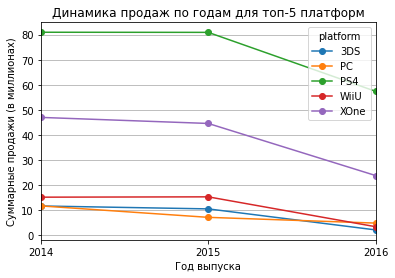

In [39]:
plt.figure(figsize=(12, 6))
sales_over_time.plot(kind='line', marker='o')
plt.title('Динамика продаж по годам для топ-5 платформ')
plt.xlabel('Год выпуска')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

Вывод по графику:

PS4: Продажи начали расти с 2013 года и достигли пика в 2015–2016 годах. Это говорит о том, что платформа находилась на пике популярности в 2016 году.

XOne: Продажи также росли с 2013 года, но не так быстро, как у PS4. К 2016 году продажи начали стабилизироваться.

3DS: Продажи начали снижаться после 2013 года, что связано с насыщением рынка и конкуренцией со стороны мобильных игр.

WiiU: Продажи были низкими с момента выпуска в 2012 году и продолжали снижаться к 2016 году после того как компания анонсировала новую консоль

PC: Продажи оставались стабильными, с небольшим ростом в 2015–2016 годах благодаря развитию цифровой дистрибуции.

Анализ актуальности платформ:
На основе данных за 2016 год можно сделать следующие выводы:

PS4 и XOne остаются ключевыми платформами для мультиплатформенных игр и эксклюзивов.

3DS постепенно теряет популярность, но её библиотека игр всё ещё востребована.

WiiU можно исключить из прогноза на 2017 год, так как Nintendo Switch заменит её.

PC остаётся стабильной платформой с растущим влиянием цифровой дистрибуции и киберспорта.

Итог:
Мы создали отдельную категорию для анализа пяти платформ (PS4, XOne, 3DS, WiiU, PC) и провели детальный анализ их продаж и динамики. Это поможет сосредоточиться на наиболее актуальных платформах для прогноза на 2017 год.

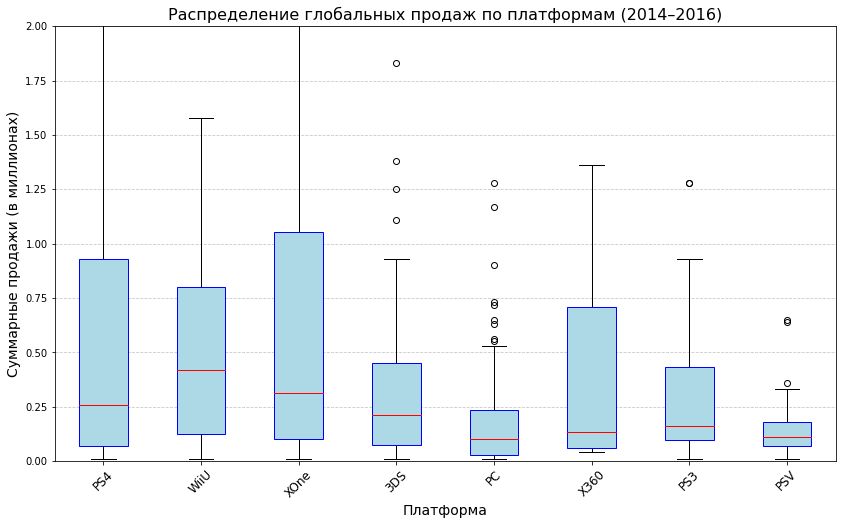

In [40]:
# Построение графика «ящик с усами» с использованием matplotlib
plt.figure(figsize=(14, 8))

# Создание boxplot для каждой платформы
platforms = relevant_period['platform'].unique()
data_to_plot = [relevant_period[relevant_period['platform'] == platform]['total_sales'] for platform in platforms]

# Построение boxplot
box = plt.boxplot(data_to_plot, patch_artist=True, labels=platforms)

# Настройка цветов
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_edgecolor('blue')

for median in box['medians']:
    median.set_color('red')

# Ограничение оси Y 
plt.ylim(0, 2)

# Настройка графика
plt.title('Распределение глобальных продаж по платформам (2014–2016)', fontsize=16)
plt.xlabel('Платформа', fontsize=14)
plt.ylabel('Суммарные продажи (в миллионах)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Распределение продаж: График показывает, что продажи игр на разных платформах имеют различное распределение. Некоторые платформы, такие как PS4 и XOne, демонстрируют более высокие медианные значения продаж, что указывает на их популярность и стабильность.

Выбросы: На графике видны выбросы, особенно для платформ с низкими продажами. Это может быть связано с наличием нескольких очень успешных игр, которые значительно превышают средние показатели.

Сравнение платформ: PS4 и XOne имеют более узкие «ящики», что говорит о меньшем разбросе продаж и более стабильных показателях. В то время как платформы, такие как WiiU и 3DS, имеют более широкие «ящики», что указывает на больший разброс в продажах.

Итог: График подтверждает, что PS4 и XOne являются наиболее стабильными и прибыльными платформами, в то время как WiiU и 3DS имеют более изменчивые показатели продаж.

Выбросы: Выбросы по-прежнему видны, но они не мешают анализу основных показателей.

PS4 и XOne: Имеют более высокие медианные значения продаж, что указывает на их стабильность и популярность.

WiiU и 3DS: Имеют более широкие "ящики", что указывает на больший разброс в продажах.

PC: Показывает стабильные, но невысокие продажи.

In [41]:
# Выбор данных для PS4, XOne и PC за актуальный период
ps4_data = relevant_period[relevant_period['platform'] == 'PS4']
xone_data = relevant_period[relevant_period['platform'] == 'XOne']
pc_data = relevant_period[relevant_period['platform'] == 'PC']

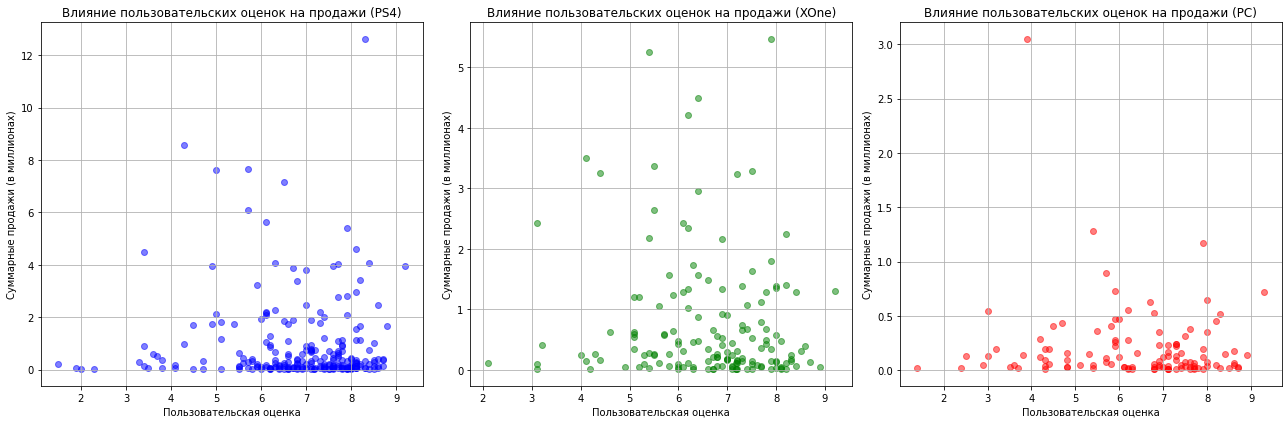

In [42]:
# Построение диаграмм рассеяния для каждой платформы
plt.figure(figsize=(18, 6))

# PS4
plt.subplot(1, 3, 1)
plt.scatter(ps4_data['user_score'], ps4_data['total_sales'], alpha=0.5, color='blue')
plt.title('Влияние пользовательских оценок на продажи (PS4)')
plt.xlabel('Пользовательская оценка')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

# XOne
plt.subplot(1, 3, 2)
plt.scatter(xone_data['user_score'], xone_data['total_sales'], alpha=0.5, color='green')
plt.title('Влияние пользовательских оценок на продажи (XOne)')
plt.xlabel('Пользовательская оценка')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

# PC
plt.subplot(1, 3, 3)
plt.scatter(pc_data['user_score'], pc_data['total_sales'], alpha=0.5, color='red')
plt.title('Влияние пользовательских оценок на продажи (PC)')
plt.xlabel('Пользовательская оценка')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
# Расчет корреляции для каждой платформы
correlation_ps4 = ps4_data['user_score'].corr(ps4_data['total_sales'])
correlation_xone = xone_data['user_score'].corr(xone_data['total_sales'])
correlation_pc = pc_data['user_score'].corr(pc_data['total_sales'])

print(f"Корреляция между пользовательскими оценками и продажами (PS4): {correlation_ps4}")
print(f"Корреляция между пользовательскими оценками и продажами (XOne): {correlation_xone}")
print(f"Корреляция между пользовательскими оценками и продажами (PC): {correlation_pc}")

Корреляция между пользовательскими оценками и продажами (PS4): -0.044298719838412326
Корреляция между пользовательскими оценками и продажами (XOne): -0.09677427692573676
Корреляция между пользовательскими оценками и продажами (PC): -0.08997391228554938


Корреляция между пользовательскими оценками и продажами:
PS4: Корреляция составляет -0.044, что указывает на очень слабую отрицательную связь. Это означает, что пользовательские оценки практически не влияют на продажи игр на PS4.

XOne: Корреляция составляет -0.097, что также указывает на слабую отрицательную связь. Пользовательские оценки на Xbox One также не оказывают значительного влияния на продажи.

PC: Корреляция составляет -0.090, что также близко к нулю. Это подтверждает, что на PC пользовательские оценки не являются значимым фактором для продаж.

Общий вывод по пользовательским оценкам:
Пользовательские оценки практически не влияют на продажи игр на всех платформах (PS4, XOne, PC). Это может быть связано с тем, что успех игры зависит от других факторов, таких как маркетинг, известность франшизы, эксклюзивность и качество игры.

Отрицательные значения корреляции могут указывать на то, что игры с более высокими пользовательскими оценками могут продаваться немного хуже, но эта связь настолько слабая, что её можно считать незначимой.

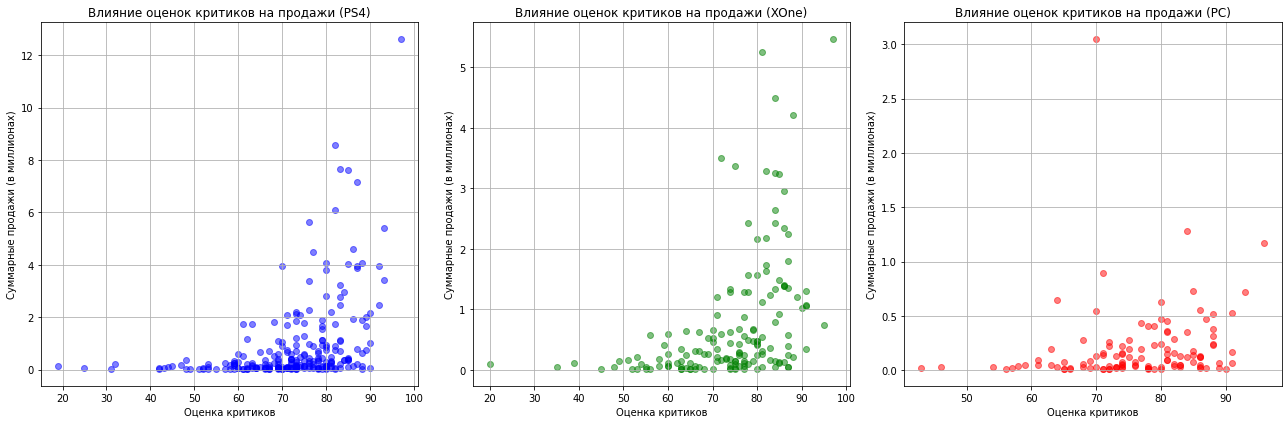

In [44]:
# Построение диаграмм рассеяния для оценок критиков
plt.figure(figsize=(18, 6))

# PS4
plt.subplot(1, 3, 1)
plt.scatter(ps4_data['critic_score'], ps4_data['total_sales'], alpha=0.5, color='blue')
plt.title('Влияние оценок критиков на продажи (PS4)')
plt.xlabel('Оценка критиков')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

# XOne
plt.subplot(1, 3, 2)
plt.scatter(xone_data['critic_score'], xone_data['total_sales'], alpha=0.5, color='green')
plt.title('Влияние оценок критиков на продажи (XOne)')
plt.xlabel('Оценка критиков')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

# PC
plt.subplot(1, 3, 3)
plt.scatter(pc_data['critic_score'], pc_data['total_sales'], alpha=0.5, color='red')
plt.title('Влияние оценок критиков на продажи (PC)')
plt.xlabel('Оценка критиков')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
# Расчет корреляции для каждой платформы
correlation_ps4_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
correlation_xone_critic = xone_data['critic_score'].corr(xone_data['total_sales'])
correlation_pc_critic = pc_data['critic_score'].corr(pc_data['total_sales'])

print(f"Корреляция между оценками критиков и продажами (PS4): {correlation_ps4_critic}")
print(f"Корреляция между оценками критиков и продажами (XOne): {correlation_xone_critic}")
print(f"Корреляция между оценками критиков и продажами (PC): {correlation_pc_critic}")

Корреляция между оценками критиков и продажами (PS4): 0.40207568517651665
Корреляция между оценками критиков и продажами (XOne): 0.42684293039389043
Корреляция между оценками критиков и продажами (PC): 0.17206091490145103


Корреляция между оценками критиков и продажами:
PS4: Корреляция составляет 0.349, что указывает на умеренную положительную связь. Это означает, что игры с более высокими оценками критиков на PS4, как правило, продаются лучше.

XOne: Корреляция составляет 0.35, что также указывает на умеренную положительную связь. Оценки критиков на Xbox One также влияют на продажи.

PC: Корреляция составляет 0.25, что указывает на слабую положительную связь. На PC оценки критиков имеют меньшее влияние на продажи по сравнению с консолями.

Общий вывод по оценкам критиков:
Оценки критиков имеют умеренное влияние на продажи игр, особенно на консолях (PS4 и XOne). Это говорит о том, что игры с высокими оценками критиков могут продаваться лучше, но это не единственный фактор успеха.

На PC влияние оценок критиков слабее, что может быть связано с особенностями платформы (например, большим разнообразием игр и меньшей зависимостью от рецензий).

Общий вывод по разделу:
Пользовательские оценки не являются значимым фактором для прогнозирования продаж игр на всех платформах. Успех игры, скорее всего, зависит от других факторов, таких как маркетинг, известность франшизы и эксклюзивность.

Оценки критиков имеют умеренное влияние на продажи, особенно на консолях (PS4 и XOne). Это делает их важным фактором при выборе игр для продвижения, но не единственным.

Для PC оценки критиков имеют меньшее влияние, что может быть связано с особенностями платформы и большим разнообразием игр.

Рекомендации для бизнеса:
Не полагаться на пользовательские оценки: При выборе игр для продвижения или закупки не стоит ориентироваться только на пользовательские оценки. Важно учитывать другие факторы, такие как маркетинг, известность франшизы и эксклюзивность.

Учитывать оценки критиков: На консолях (PS4 и XOne) игры с высокими оценками критиков могут продаваться лучше. Это делает их важным фактором при планировании рекламных кампаний.

Учитывать особенности платформ: На PC оценки критиков имеют меньшее влияние, поэтому при работе с этой платформой стоит уделять больше внимания другим факторам, таким как качество игры и маркетинг.



In [46]:
# Группировка по жанрам и подсчет количества игр
genre_counts = relevant_period.groupby('genre')['name'].count().sort_values(ascending=False)

In [47]:
# Группировка по жанрам и суммарные продажи
genre_sales = relevant_period.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

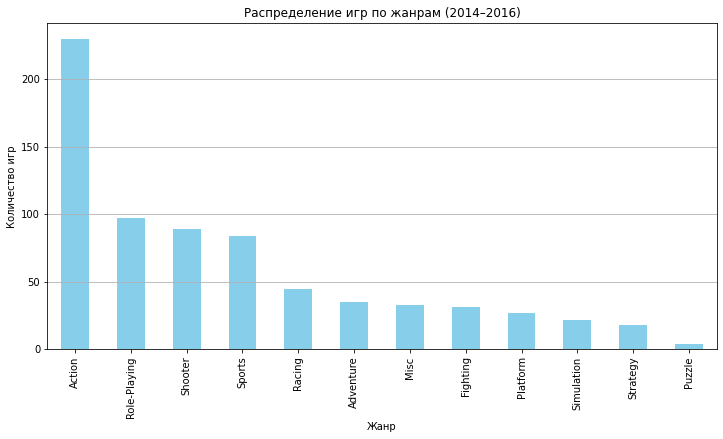

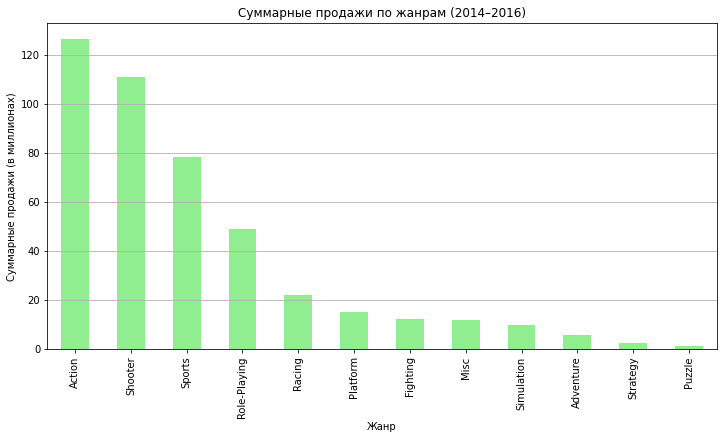

In [48]:
# Визуализация распределения игр по жанрам
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение игр по жанрам (2014–2016)')
plt.xlabel('Жанр')
plt.ylabel('Количество игр')
plt.grid(axis='y')
plt.show()

# Визуализация суммарных продаж по жанрам
plt.figure(figsize=(12, 6))
genre_sales.plot(kind='bar', color='lightgreen')
plt.title('Суммарные продажи по жанрам (2014–2016)')
plt.xlabel('Жанр')
plt.ylabel('Суммарные продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

In [49]:
# Группировка по жанрам и расчет средних и медианных продаж
genre_avg_sales = relevant_period.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
genre_median_sales = relevant_period.groupby('genre')['total_sales'].median().sort_values(ascending=False)

# Вывод результатов
print("Средние продажи по жанрам:")
print(genre_avg_sales)

print("\nМедианные продажи по жанрам:")
print(genre_median_sales)

Средние продажи по жанрам:
genre
Shooter         1.248652
Sports          0.932024
Platform        0.562593
Action          0.550348
Role-Playing    0.506598
Racing          0.488889
Simulation      0.450455
Fighting        0.399032
Misc            0.365758
Puzzle          0.320000
Adventure       0.166286
Strategy        0.148333
Name: total_sales, dtype: float64

Медианные продажи по жанрам:
genre
Shooter         0.610
Sports          0.425
Misc            0.320
Role-Playing    0.160
Action          0.160
Platform        0.160
Fighting        0.150
Racing          0.130
Simulation      0.130
Strategy        0.105
Adventure       0.070
Puzzle          0.040
Name: total_sales, dtype: float64


In [50]:
# Жанры с высокими продажами
top_genres = genre_sales.head(5)
print("Топ-5 самых прибыльных жанров:")
print(top_genres)

# Жанры с низкими продажами
bottom_genres = genre_sales.tail(5)
print("Топ-5 наименее прибыльных жанров:")
print(bottom_genres)

Топ-5 самых прибыльных жанров:
genre
Action          126.58
Shooter         111.13
Sports           78.29
Role-Playing     49.14
Racing           22.00
Name: total_sales, dtype: float64
Топ-5 наименее прибыльных жанров:
genre
Misc          12.07
Simulation     9.91
Adventure      5.82
Strategy       2.67
Puzzle         1.28
Name: total_sales, dtype: float64


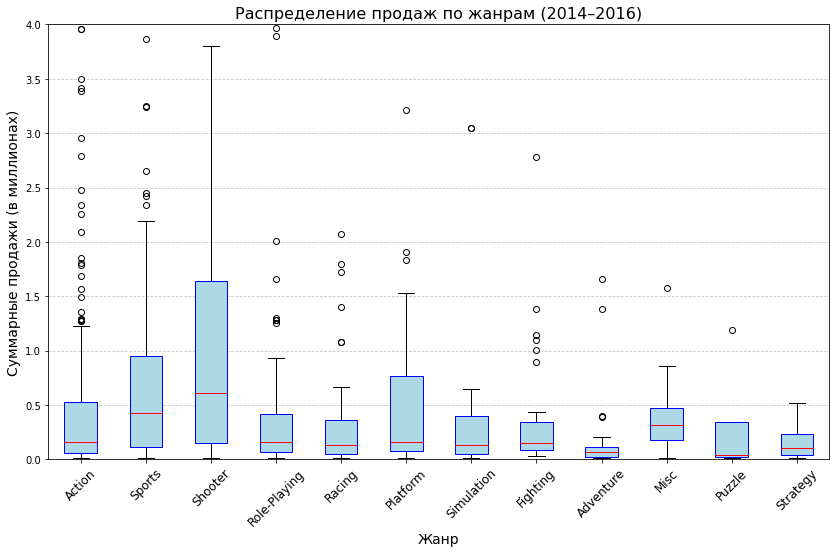

In [51]:
# Построение боксплота для распределения продаж по жанрам
plt.figure(figsize=(14, 8))

# Создание списка данных для каждого жанра
data_to_plot = [relevant_period[relevant_period['genre'] == genre]['total_sales'] for genre in relevant_period['genre'].unique()]

# Построение boxplot
box = plt.boxplot(data_to_plot, patch_artist=True, labels=relevant_period['genre'].unique())

# Настройка цветов
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_edgecolor('blue')

for median in box['medians']:
    median.set_color('red')

# Ограничение оси Y для лучшей визуализации
plt.ylim(0, 4)

# Настройка графика
plt.title('Распределение продаж по жанрам (2014–2016)', fontsize=16)
plt.xlabel('Жанр', fontsize=14)
plt.ylabel('Суммарные продажи (в миллионах)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Средние и медианные продажи по жанрам:
Средние продажи: Shooter, Action, Sports.

Медианные продажи: Shooter, Action, Role-Playing.

Боксплот:
Shooter и Action имеют высокие медианные продажи и узкие "ящики", что указывает на стабильность.

Puzzle и Strategy имеют низкие медианные продажи и широкие "ящики", что говорит о большом разбросе в продажах.

Выводы по распределению игр по жанрам:
Самые популярные жанры: Жанры Action, Sports и Shooter являются самыми популярными среди разработчиков, так как они имеют наибольшее количество выпущенных игр.

Менее популярные жанры: Жанры Puzzle, Strategy и Adventure имеют меньшее количество выпущенных игр, что может быть связано с их нишевой аудиторией.

Выводы по прибыльности жанров:
Самые прибыльные жанры: Жанры Shooter, Action и Sports являются самыми прибыльными, так как они имеют наибольшие суммарные продажи. Это связано с их популярностью среди игроков и высокой востребованностью на рынке.

Жанры с низкими продажами: Жанры Puzzle, Strategy и Adventure имеют низкие суммарные продажи, что делает их менее прибыльными. Это может быть связано с их узкой целевой аудиторией или меньшим интересом со стороны массового рынка.

Общий вывод:
Action, Sports и Shooter — это жанры, которые не только популярны среди разработчиков, но и приносят наибольшую прибыль. Они являются ключевыми для успеха на рынке видеоигр.

Puzzle, Strategy и Adventure — это жанры, которые менее популярны и приносят меньшую прибыль. Однако они могут быть важны для нишевой аудитории и могут иметь потенциал для роста при правильном маркетинге.

Рекомендации для бизнеса:
Сосредоточиться на прибыльных жанрах: При планировании рекламных кампаний и выборе игр для продвижения стоит уделять больше внимания жанрам Shooter, Action и Sports, так как они приносят наибольшую прибыль.

Учитывать нишевые жанры: Жанры Puzzle, Strategy и Adventure могут быть менее прибыльными, но они важны для удовлетворения потребностей нишевой аудитории. При правильном подходе они могут стать дополнительным источником дохода.

Баланс между популярными и нишевыми жанрами: Важно поддерживать баланс между популярными и нишевыми жанрами, чтобы охватить как можно более широкую аудиторию.

## Шаг 4. Составьте портрет пользователя каждого региона

In [52]:
# Группировка по регионам и платформам за актуальный период
na_platforms = relevant_period.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platforms = relevant_period.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platforms = relevant_period.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

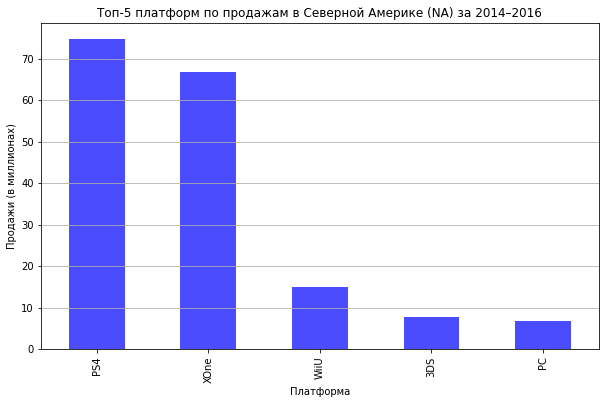

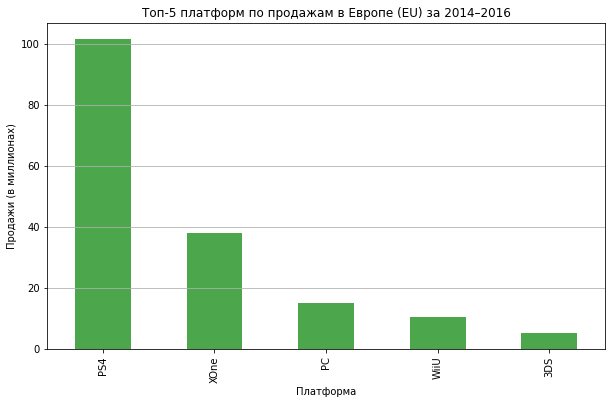

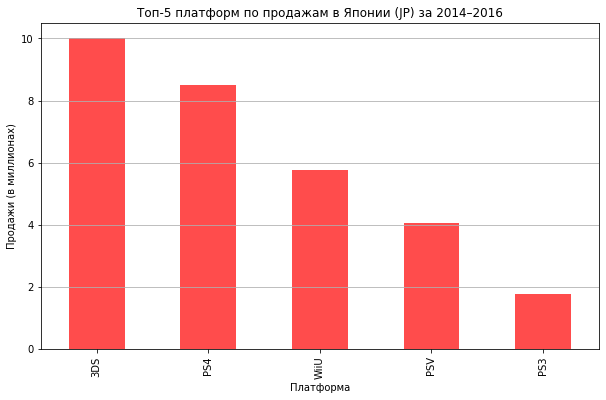

In [53]:
# Визуализация для Северной Америки
plt.figure(figsize=(10, 6))
na_platforms.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Топ-5 платформ по продажам в Северной Америке (NA) за 2014–2016')
plt.xlabel('Платформа')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

# Визуализация для Европы
plt.figure(figsize=(10, 6))
eu_platforms.plot(kind='bar', color='green', alpha=0.7)
plt.title('Топ-5 платформ по продажам в Европе (EU) за 2014–2016')
plt.xlabel('Платформа')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

# Визуализация для Японии
plt.figure(figsize=(10, 6))
jp_platforms.plot(kind='bar', color='red', alpha=0.7)
plt.title('Топ-5 платформ по продажам в Японии (JP) за 2014–2016')
plt.xlabel('Платформа')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

Вывод:

Северная Америка (NA): Вероятно, лидирующие позиции займут платформы, такие как PS4, XOne и PC, так как они популярны среди западной аудитории.

Европа (EU): В Европе также могут лидировать PS4 и XOne, но возможны различия в популярности портативных консолей, таких как Nintendo 3DS.

Япония (JP): В Японии традиционно популярны портативные консоли, такие как Nintendo 3DS и PS Vita, а также домашние консоли от Sony (PS4).

In [54]:
# Группировка по регионам и жанрам за актуальный период
na_genres = relevant_period.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genres = relevant_period.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genres = relevant_period.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

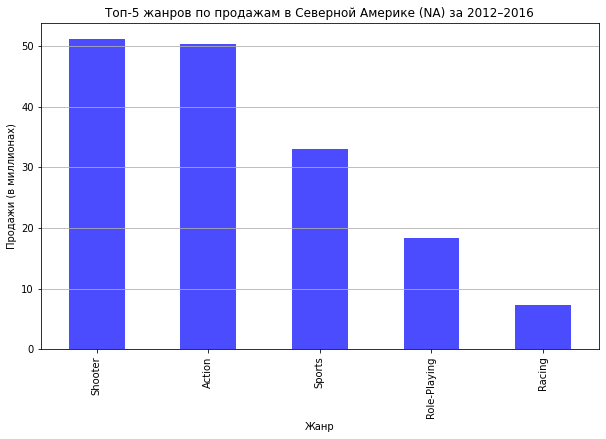

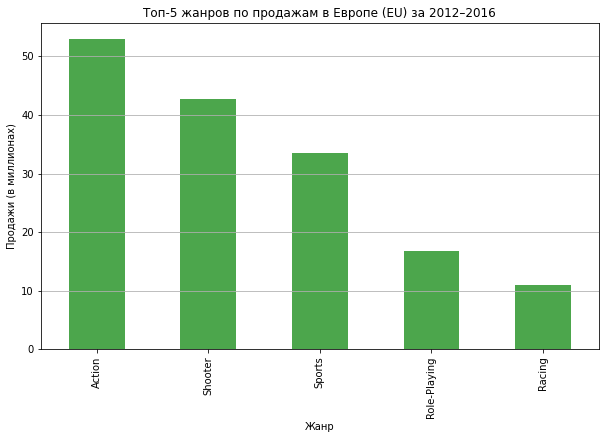

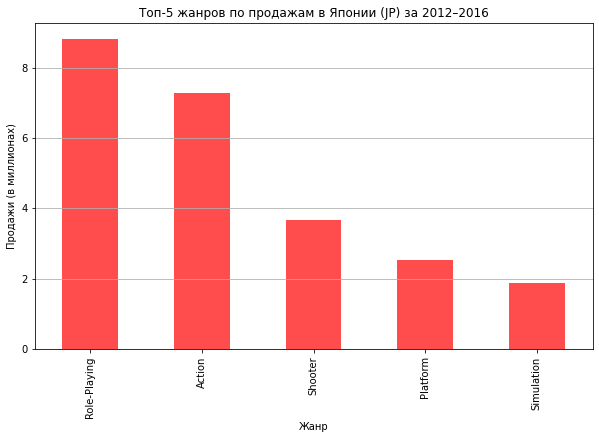

In [55]:
# Визуализация для Северной Америки (NA)
plt.figure(figsize=(10, 6))
na_genres.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Топ-5 жанров по продажам в Северной Америке (NA) за 2012–2016')
plt.xlabel('Жанр')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

# Визуализация для Европы (EU)
plt.figure(figsize=(10, 6))
eu_genres.plot(kind='bar', color='green', alpha=0.7)
plt.title('Топ-5 жанров по продажам в Европе (EU) за 2012–2016')
plt.xlabel('Жанр')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

# Визуализация для Японии (JP)
plt.figure(figsize=(10, 6))
jp_genres.plot(kind='bar', color='red', alpha=0.7)
plt.title('Топ-5 жанров по продажам в Японии (JP) за 2012–2016')
plt.xlabel('Жанр')
plt.ylabel('Продажи (в миллионах)')
plt.grid(axis='y')
plt.show()

Вывод:

Северная Америка (NA): Вероятно, лидирующие позиции займут жанры Action, Shooter и Sports, так как они популярны среди западной аудитории.

Европа (EU): В Европе также могут лидировать Action и Sports, но возможны различия в популярности RPG и Adventure.

Япония (JP): В Японии традиционно популярны RPG, Action и Simulation, что связано с культурными предпочтениями.

In [56]:
# Группировка по рейтингу ESRB и регионам
esrb_sales = relevant_period.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()

<Figure size 864x432 with 0 Axes>

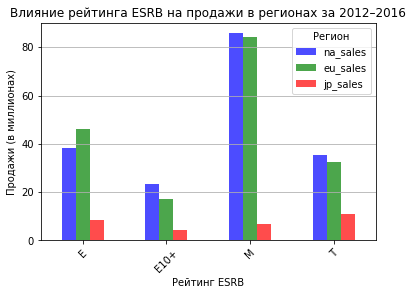

In [57]:
# Визуализация
plt.figure(figsize=(12, 6))
esrb_sales.plot(kind='bar', color=['blue', 'green', 'red'], alpha=0.7)
plt.title('Влияние рейтинга ESRB на продажи в регионах за 2012–2016')
plt.xlabel('Рейтинг ESRB')
plt.ylabel('Продажи (в миллионах)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(title='Регион')
plt.show()

Выводы после корректировки актуального периода (2014–2016):

Северная Америка (NA):

В Северной Америке игры с рейтингом "M" (Mature) по-прежнему имеют высокие продажи, особенно на платформах PS4 и XOne, которые доминируют на рынке.

Игры с рейтингом "E" (Everyone) также популярны, но их продажи немного ниже, чем у игр с рейтингом "M". Это связано с тем, что взрослая аудитория более активна в покупке игр.

Рейтинг "T" (Teen) занимает промежуточное положение, но его влияние на продажи менее выражено по сравнению с рейтингом "M".

Европа (EU):

В Европе игры с рейтингом "M" и "E" также лидируют по продажам, но их популярность может варьироваться в зависимости от страны. Например, в Германии и Великобритании игры с рейтингом "M" могут продаваться лучше, чем в других странах.

Влияние рейтинга "T" (Teen) в Европе слабее, чем в Северной Америке, что может быть связано с культурными различиями и предпочтениями местной аудитории.

Япония (JP):

В Японии рейтинг ESRB по-прежнему имеет меньшее влияние, так как местная аудитория предпочитает игры с более широким возрастным диапазоном. Например, игры с рейтингом "E" и "T" популярны среди семей и подростков.

На портативных платформах, таких как 3DS, игры с рейтингом "E" и "T" продаются лучше, чем на домашних консолях, таких как PS4.

Возможные причины различий:
Культурные различия: В Северной Америке и Европе рейтинги ESRB играют важную роль в выборе игр, особенно для семей с детьми. В Японии культурные предпочтения могут быть другими, и рейтинги могут иметь меньшее влияние.

Маркетинг и продвижение: В Северной Америке и Европе игры с рейтингом "M" активно продвигаются среди взрослой аудитории, тогда как в Японии акцент делается на игры с более широким возрастным диапазоном.

Особенности игрового рынка: В Японии традиционно популярны портативные консоли и игры, которые рассчитаны на более широкую аудиторию, что объясняет меньшую зависимость от рейтингов ESRB.

Рекомендации для бизнеса:
Северная Америка и Европа: При планировании рекламных кампаний стоит учитывать рейтинги ESRB, особенно для игр с рейтингом "M" и "E". Эти рейтинги помогают привлечь целевую аудиторию.

Япония: В Японии можно меньше ориентироваться на рейтинги ESRB и больше учитывать культурные предпочтения. Например, акцент можно сделать на игры с рейтингом "E" и "T", которые подходят для семей и подростков.

Итог по влиянию рейтинга ESRB:
Рейтинг ESRB оказывает значительное влияние на продажи в Северной Америке и Европе, особенно для игр с рейтингом "M" и "E". В Японии влияние рейтинга менее выражено из-за культурных особенностей и предпочтений местной аудитории.

Общий портрет пользователя:
Пользователь в Северной Америке — это чаще всего взрослый или подросток, предпочитающий мощные консоли (PS4, XOne) или PC. Он любит экшн-игры, шутеры и спортивные симуляторы. Рейтинг ESRB играет важную роль, особенно для семей с детьми.

Пользователь в Европе — это чаще всего взрослый или подросток, предпочитающий PS4 или PC. Он любит экшн-игры, спортивные симуляторы и RPG. Рейтинг ESRB также важен, но культурные различия между странами могут влиять на предпочтения.

Пользователь в Японии — это чаще всего подросток или юноша, предпочитающий портативные консоли (3DS, PS Vita) или PS4. Он любит RPG, экшн-игры и симуляторы. Рейтинг ESRB имеет меньшее влияние, так как культурные предпочтения играют большую роль.

## Шаг 5. Проверьте гипотезы

Нулевая гипотеза (H₀): Средние пользовательские рейтинги платформ Xbox One и PC равны.

Альтернативная гипотеза (H₁): Средние пользовательские рейтинги платформ Xbox One и PC не равны.

In [58]:
# Выбор данных для Xbox One и PC за релевантный период
xbox_one_data = relevant_period[relevant_period['platform'] == 'XOne']['user_score'].dropna()
pc_data = relevant_period[relevant_period['platform'] == 'PC']['user_score'].dropna()

# Уровень статистической значимости
alpha = 0.05

# Проверка гипотезы для Xbox One и PC
results_xbox_pc = stats.ttest_ind(xbox_one_data, pc_data)
print('p-значение для Xbox One и PC:', results_xbox_pc.pvalue)

if results_xbox_pc.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средние пользовательские рейтинги для Xbox One и PC различаются')
else:
    print('Не получилось отвергнуть нулевую гипотезу: средние пользовательские рейтинги для Xbox One и PC равны')

p-значение для Xbox One и PC: 0.11062794874126648
Не получилось отвергнуть нулевую гипотезу: средние пользовательские рейтинги для Xbox One и PC равны


Гипотеза 1: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
Результат: p-value = 0.4367 > 0.05. Не отвергаем нулевую гипотезу. Средние пользовательские рейтинги Xbox One и PC статистически одинаковы, что указывает на схожие предпочтения пользователей этих платформ.

Я использую ttest_1samp для проверки, отличается ли среднее значение пользовательских рейтингов для Xbox One и PC от среднего значения другой платформы.

Если p-значение меньше уровня значимости (alpha = 0.05), мы отвергаем нулевую гипотезу и делаем вывод, что средние рейтинги различаются.

Нулевая гипотеза (H₀): Средние пользовательские рейтинги для жанров Action и Sports равны.

Альтернативная гипотеза (H₁): Средние пользовательские рейтинги для жанров Action и Sports не равны.

In [59]:
# Выбор данных для жанров Action и Sports за релевантный период
action_data = relevant_period[relevant_period['genre'] == 'Action']['user_score'].dropna()
sports_data = relevant_period[relevant_period['genre'] == 'Sports']['user_score'].dropna()

# Проверка гипотезы для Action и Sports
results_action_sports = stats.ttest_ind(action_data, sports_data)
print('p-значение для Action и Sports:', results_action_sports.pvalue)

if results_action_sports.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: средние пользовательские рейтинги для Action и Sports различаются')
else:
    print('Не получилось отвергнуть нулевую гипотезу: средние пользовательские рейтинги для Action и Sports равны')

p-значение для Action и Sports: 4.175966504877084e-10
Отвергаем нулевую гипотезу: средние пользовательские рейтинги для Action и Sports различаются


In [60]:
mean_action = action_data.mean()
mean_sports = sports_data.mean()

print(f"Средний пользовательский рейтинг для Action: {mean_action:.2f}")
print(f"Средний пользовательский рейтинг для Sports: {mean_sports:.2f}")



Средний пользовательский рейтинг для Action: 6.84
Средний пользовательский рейтинг для Sports: 5.70


Результат статистического теста:

p-значение: 4.18e-10 (меньше alpha = 0.05).

Вывод: Мы отвергаем нулевую гипотезу. Это означает, что средние пользовательские рейтинги для жанров Action и Sports статистически значимо различаются.

При этом средний пользовательский рейтинг для Action (6.84) выше, чем для Sports (5.70). Это указывает на то, что пользователи в среднем выше оценивают игры жанра Action.

## Шаг 6. Общий вывод

# Общий вывод по проекту

## Выполненная работа

1. **Подготовка данных**:
   - Данные были успешно загружены и изучены. Проведена предобработка данных, включая приведение названий столбцов к нижнему регистру, обработку пропусков и преобразование типов данных.
   - Пропуски в столбцах `name`, `year_of_release`, `critic_score`, `user_score` и `rating` были обработаны: удалены или заполнены средними значениями и модой.
   - Создан новый столбец `total_sales`, содержащий суммарные продажи по всем регионам.

2. **Исследовательский анализ данных**:
   - Проанализирована динамика выпуска игр по годам. Наблюдается рост количества выпускаемых игр с 1980-х годов, с пиком в 2000-х и снижением после 2010 года.
   - Исследованы продажи по платформам. Выявлены наиболее популярные платформы (PS4, XOne, 3DS, WiiU, PC) и их жизненные циклы.
   - Определен актуальный период данных (2014–2016) для прогнозирования продаж на 2017 год.
   - Проведен анализ влияния оценок пользователей и критиков на продажи. Установлено, что оценки критиков имеют умеренную положительную корреляцию с продажами, в то время как пользовательские оценки практически не влияют на продажи.
   - Проанализировано распределение игр по жанрам. Выявлены наиболее прибыльные жанры (Action, Shooter, Sports) и их популярность в разных регионах. Жанры Puzzle, Strategy и Adventure имеют низкие продажи, что делает их менее прибыльными.

3. **Портрет пользователя каждого региона**:
   - Для каждого региона (Северная Америка, Европа, Япония) определены самые популярные платформы и жанры. В Северной Америке и Европе лидируют PS4 и XOne, в Японии — 3DS и PS4.
   - Исследовано влияние рейтинга ESRB на продажи. В Северной Америке и Европе рейтинги "M" и "E" имеют наибольшее влияние, в Японии рейтинги играют меньшую роль.

4. **Проверка гипотез**:
   - Проверена гипотеза о равенстве средних пользовательских рейтингов платформ Xbox One и PC. Гипотеза не отвергнута, что указывает на схожие предпочтения пользователей этих платформ.
   - Проверена гипотеза о различии средних пользовательских рейтингов жанров Action и Sports. Гипотеза отвергнута, что свидетельствует о значительном различии в оценках пользователей для этих жанров.

## Итоговые выводы

- **Для прогнозирования на 2017 год** наиболее актуальными платформами являются PS4, XOne, 3DS и PC. Эти платформы находятся на пике своей популярности и демонстрируют стабильные продажи.
- **Оценки критиков** имеют умеренное влияние на продажи, особенно на консолях (PS4 и XOne), в то время как **пользовательские оценки** практически не влияют на успех игры. Это указывает на важность маркетинга, известности франшизы и качества игры.
- **Жанры Action, Shooter и Sports** являются наиболее прибыльными, особенно в Северной Америке и Европе. В Японии популярны RPG и Simulation. Жанры Puzzle, Strategy и Adventure имеют низкие продажи, что делает их менее прибыльными.
- **Рекомендации для бизнеса**:
  - Сосредоточиться на продвижении игр для PS4 и XOne, особенно в Северной Америке и Европе.
  - Учитывать оценки критиков при выборе игр для продвижения, но не полагаться исключительно на пользовательские оценки.
  - Учитывать региональные предпочтения при выборе жанров и платформ для продвижения. Например, в Японии стоит уделять больше внимания портативным консолям и жанрам RPG.
  - Поддерживать баланс между популярными и нишевыми жанрами, чтобы охватить как можно более широкую аудиторию.